In [1]:
import hea
import polars as pl


### Replication of Ran et al. (2020)

### Figure 4d

In [2]:
d1 = pl.read_csv("https://raw.githubusercontent.com/berenslab/rgc_dendrites/refs/heads/master/data/processed/overlap.csv")

d1 = hea.tbl(d1).rename(
    roi_dist="dendritic_distance_between_rois", 
    angle="cbpt_angle_between_rois_deg",
    overlap="overlap_index", 
)
d1 = d1.select("cell_id", "type", "roi_dist", "overlap", "angle")
d1 = d1.with_columns(
    hea.factor(
        d1["type"].cast(pl.Int64), 
        labels={"0":"alpha transient", "1":"sustained", "2":"mini alpha", "3":"f-mini"}
    ), 
)

offsets = (
    d1.sort("type")
      .group_by("type", maintain_order=True)
      .agg((pl.col("cell_id").max() + 1).alias("step"))
      .with_columns(pl.col("step").cum_sum().shift(1, fill_value=0).alias("offset"))
      .select("type", "offset")
)
d1 = hea.tbl(
    d1.join(offsets, on="type")
      .with_columns(cell_id=pl.col("cell_id") + pl.col("offset"))
      .drop("offset")
)

d1 = d1.filter((pl.col("roi_dist") < 300))
d1 = d1.with_columns(hea.factor(d1["cell_id"].cast(pl.Int64)))

In [3]:
d1

cell_id,type,roi_dist,overlap,angle
enum,enum,f64,f64,f64
"""0""","""alpha transient""",11.655505,0.867386,132.988429
"""0""","""alpha transient""",3.325,0.97784,18.434949
"""0""","""alpha transient""",23.235176,0.918401,90.0
"""0""","""alpha transient""",30.507996,0.918557,65.149677
"""0""","""alpha transient""",9.281426,0.96853,81.869898
…,…,…,…,…
"""30""","""f-mini""",9.72642,0.911793,121.010898
"""30""","""f-mini""",3.274087,0.93578,7.958054
"""30""","""f-mini""",5.193016,0.999633,0.0


In [4]:
m1_d1 = hea.bam('overlap ~ type + te(roi_dist, angle, by=type, k=20)', data = d1)
m1_d1.summary()


Family: gaussian
Link function: identity

Formula: overlap ~ type + te(roi_dist, angle, by=type, k=20)

Parametric coefficients:
                 Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)     0.4712566   0.0008136   579.24    <2e-16  ***
typesustained   0.3645318   0.0041665    87.49    <2e-16  ***
typemini alpha  0.2587807   0.0030507    84.83    <2e-16  ***
typef-mini      0.4482529   0.0348732    12.85    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                                           edf  Ref.df        F   p-value
te(roi_dist,angle):typealpha transient  221.47  274.96  475.117   < 2e-16  ***
te(roi_dist,angle):typesustained         74.58  100.30    6.245   < 2e-16  ***
te(roi_dist,angle):typemini alpha       182.22  232.76   34.799   < 2e-16  ***
te(roi_dist,angle):typef-mini            52.96   71.47    2.609  3.51e-12  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [5]:
m2_d1 = hea.bam('overlap ~ type + te(roi_dist, angle, by=type, k=20) + s(cell_id, bs="re")', data = d1)
m2_d1.summary()


Family: gaussian
Link function: identity

Formula: overlap ~ type + te(roi_dist, angle, by=type, k=20) + s(cell_id, bs="re")

Parametric coefficients:
                Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)      0.53414     0.02416   22.110   < 2e-16  ***
typesustained    0.27417     0.05500    4.985  6.22e-07  ***
typemini alpha   0.21818     0.05044    4.325  1.52e-05  ***
typef-mini       0.27518     0.05094    5.402  6.61e-08  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                                            edf   Ref.df        F  p-value
te(roi_dist,angle):typealpha transient  214.825  268.390  469.688  < 2e-16  ***
te(roi_dist,angle):typesustained         45.139   62.695    9.305  < 2e-16  ***
te(roi_dist,angle):typemini alpha       191.013  242.159   35.503  < 2e-16  ***
te(roi_dist,angle):typef-mini             4.522    5.633    3.358  0.00329  **
s(cell_id)                               26.5

In [6]:
m1_d1_discrete = hea.bam('overlap ~ type + te(roi_dist, angle, by=type, k=20)', data = d1, discrete=True)
m1_d1_discrete.summary()


Family: gaussian
Link function: identity

Formula: overlap ~ type + te(roi_dist, angle, by=type, k=20)

Parametric coefficients:
                 Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)     0.4670636   0.0009433   495.14    <2e-16  ***
typesustained   0.3743781   0.0033225   112.68    <2e-16  ***
typemini alpha  0.2649228   0.0018546   142.85    <2e-16  ***
typef-mini      0.2430812   0.0041110    59.13    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                                            edf   Ref.df       F  p-value
te(roi_dist,angle):typealpha transient  214.584  268.361  20.391  < 2e-16  ***
te(roi_dist,angle):typesustained          3.031    3.055   5.031  0.00162  **
te(roi_dist,angle):typemini alpha         3.015    3.027   3.850  0.00890  **
te(roi_dist,angle):typef-mini             3.014    3.025   4.134  0.00599  **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-

In [ ]:
m2_d1_discrete = hea.bam('overlap ~ type + te(roi_dist, angle, by=type, k=20) + s(cell_id, bs="re")', data = d1, discrete=True)
m2_d1_discrete.summary()

In [ ]:
hea.AIC(m1_d1, m2_d1)

               df        AIC
m1_d1  246.576432  -51968.86
m2_d1  234.893584  -57949.35


In [ ]:
hea.AIC(m1_d1, m1_d1_discrete)

                        df        AIC
m1_d1           246.576432  -51968.86
m1_d1_discrete   93.057909  -35386.07


In [ ]:
hea.AIC(m2_d1, m2_d1_discrete)

                        df        AIC
m2_d1           234.893584  -57949.35
m2_d1_discrete  126.795501  -42090.32


<Axes: title={'center': 'Normal Q-Q'}, xlabel='Theoretical Quantiles', ylabel='Std. deviance resid.'>

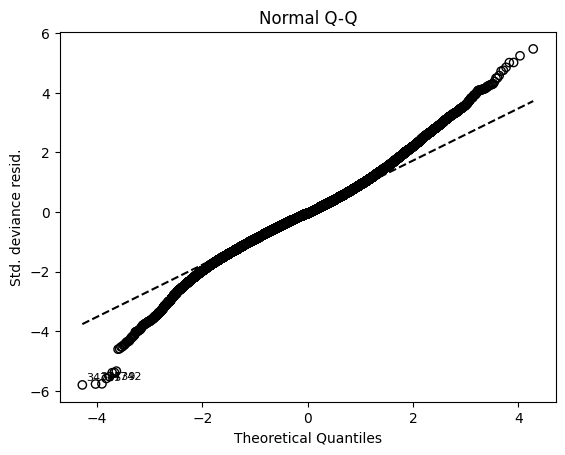

In [ ]:
m2_d1.plot_qq()

In [ ]:
m3 = bam('overlap ~ type + te(roi_dist, angle, by=type, k=20) + s(cell_id, bs="re")', 
          data =d1, 
          family=scat(min.df=5), 
          discrete=TRUE)